# Student Performance Analysis

## Research Question

How do study time, absences, and previous class failures relate to students' final math grades?

This project analyzes student performance data to explore whether study habits, school absences, and previous class failures are related to students' final math performance.

## Dataset Acquisition

The dataset used in this project comes from the UCI Machine Learning Repository's Student Performance dataset.

To meet the data acquisition requirement, I used both an API and web scraping. The UCI dataset was accessed through Python, and the official UCI webpage was scraped to locate the downloadable dataset file. The mathematics dataset was then downloaded and extracted programmatically rather than being manually downloaded.

### Data Acquisition Ethics

The dataset was obtained from the official UCI Machine Learning Repository. I used a single request to the official UCI webpage to locate the publicly available download link and did not use login credentials or make excessive requests. The dataset was downloaded programmatically from the official source.

In [2]:
# Install the packages needed to access and scrape the dataset
%pip install ucimlrepo beautifulsoup4 requests


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from ucimlrepo import fetch_ucirepo

# Access the Student Performance dataset through the UCI API
student_performance = fetch_ucirepo(id=320)

print("Dataset:", student_performance.metadata.name)
print("API data shape:", student_performance.data.original.shape)

Dataset: Student Performance
API data shape: (649, 33)


In [2]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

# Scrape the official UCI webpage to find the dataset download link
page_url = "https://archive.ics.uci.edu/dataset/320/student%2Bperformance"

page_response = requests.get(page_url)
soup = BeautifulSoup(page_response.text, "html.parser")

download_link = None

for link in soup.find_all("a", href=True):
    href = link["href"]
    text = link.get_text(strip=True)

    if "Download" in text or ".zip" in href:
        download_link = urljoin(page_url, href)
        break

print("Download link found:", download_link)

Download link found: https://archive.ics.uci.edu/static/public/320/student+performance.zip


In [3]:
# Download the dataset using the scraped link

response = requests.get(download_link)

print("Download status:", response.status_code)
print("Downloaded file size:", len(response.content), "bytes")

Download status: 200
Downloaded file size: 40735 bytes


In [4]:
# Extract the mathematics dataset from the downloaded ZIP file

from io import BytesIO
import zipfile

with zipfile.ZipFile(BytesIO(response.content)) as z:
    # Open the inner student.zip file
    student_zip = z.read("student.zip")

with zipfile.ZipFile(BytesIO(student_zip)) as z:
    # Extract the mathematics CSV
    with open("student-mat.csv", "wb") as f:
        f.write(z.read("student-mat.csv"))

print("Mathematics dataset extracted successfully!")

Mathematics dataset extracted successfully!


In [5]:
import pandas as pd

# Load the mathematics dataset
df = pd.read_csv("student-mat.csv", sep=";")

# Show the size of the dataset
print("Dataset shape:", df.shape)

# Show the first 5 rows
df.head()

Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
# Check for missing values
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

## Dataset Description

The dataset used in this project is the Student Performance dataset from the UCI Machine Learning Repository. The dataset contains information about students from two Portuguese secondary schools.

For this project, I use the mathematics dataset, which contains 395 student records and 33 columns.

The unit of analysis is one student, meaning each row represents an individual student.

The dataset includes demographic information, family and school information, study habits, absences, previous class failures, and student grades. For this analysis, the main variables are `studytime`, `absences`, `failures`, and `G3`.

The dataset contains no missing values, as confirmed by checking each column with `df.isnull().sum()`.

## Data Cleaning

I checked the dataset for missing values using `df.isnull().sum()`. All columns had 0 missing values, so no rows needed to be removed and no missing values needed to be filled.

I kept the original values for study time, absences, previous class failures, and final grade because these variables are important to the research question. I also kept the study time categories as provided by the original dataset rather than changing them into exact hours.

## Conceptualization and Operationalization

### Study Time

**Conceptual definition:** Study time refers to the amount of time a student spends studying outside of regular class time.

**Operational definition:** Study time is measured using the dataset's `studytime` variable. It has four categories: less than 2 hours, 2–5 hours, 5–10 hours, and more than 10 hours per week.

### Absences

**Conceptual definition:** Absences represent how often a student misses school.

**Operational definition:** Absences are measured using the `absences` variable, which records the number of school absences for each student.

### Previous Class Failures

**Conceptual definition:** Previous class failures represent a student's history of failing classes before the current course.

**Operational definition:** Previous class failures are measured using the `failures` variable, which records the number of previous class failures from 0 to 3.

### Final Math Grade

**Conceptual definition:** Final math grade represents a student's academic performance in the mathematics course.

**Operational definition:** Final math grade is measured using the `G3` variable, which records the student's final mathematics grade on a scale from 0 to 20.

In [7]:
# Look at the main variables used in this project
df[["studytime", "absences", "failures", "G3"]].describe()

,studytime,absences,failures,G3
count,395.000000,395.000000,395.000000,395.000000
mean,2.035443,5.708861,0.334177,10.415190
std,0.839240,8.003096,0.743651,4.581443
min,1.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,8.000000
50%,2.000000,4.000000,0.000000,11.000000
75%,2.000000,8.000000,0.000000,14.000000
max,4.000000,75.000000,3.000000,20.000000


In [8]:
df["studytime"].value_counts().sort_index()

studytime
1    105
2    198
3     65
4     27
Name: count, dtype: int64

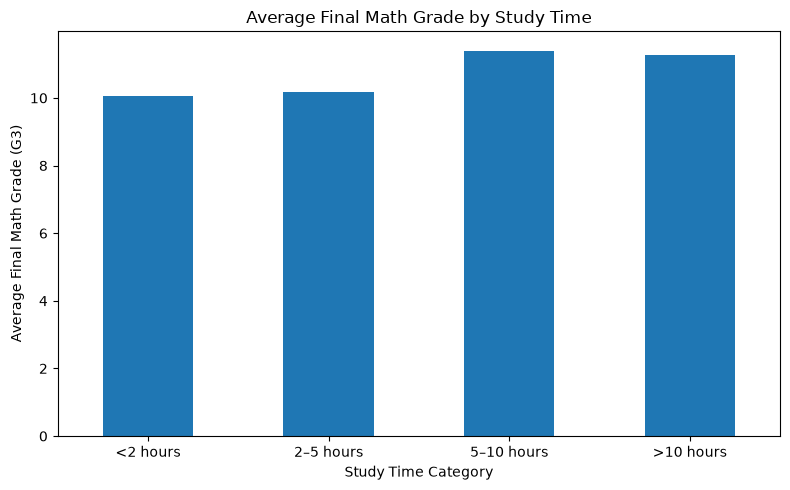

In [9]:
import matplotlib.pyplot as plt

# Calculate the average final grade for each study-time category
average_grade_by_study = df.groupby("studytime")["G3"].mean()

# Create the bar chart
plt.figure(figsize=(8, 5))
average_grade_by_study.plot(kind="bar")

plt.title("Average Final Math Grade by Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Average Final Math Grade (G3)")
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=["<2 hours", "2–5 hours", "5–10 hours", ">10 hours"],
    rotation=0
)

plt.tight_layout()
plt.show()

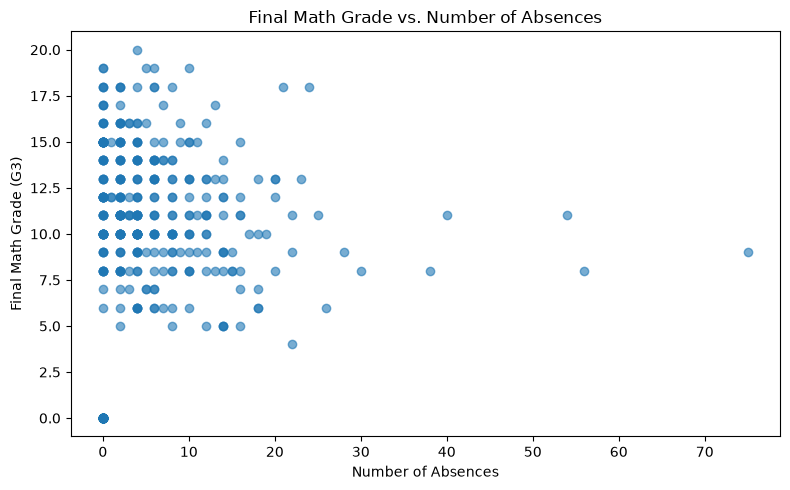

In [10]:
# Create a scatterplot of absences and final math grade

plt.figure(figsize=(8, 5))

plt.scatter(df["absences"], df["G3"], alpha=0.6)

plt.title("Final Math Grade vs. Number of Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Final Math Grade (G3)")

plt.tight_layout()
plt.show()

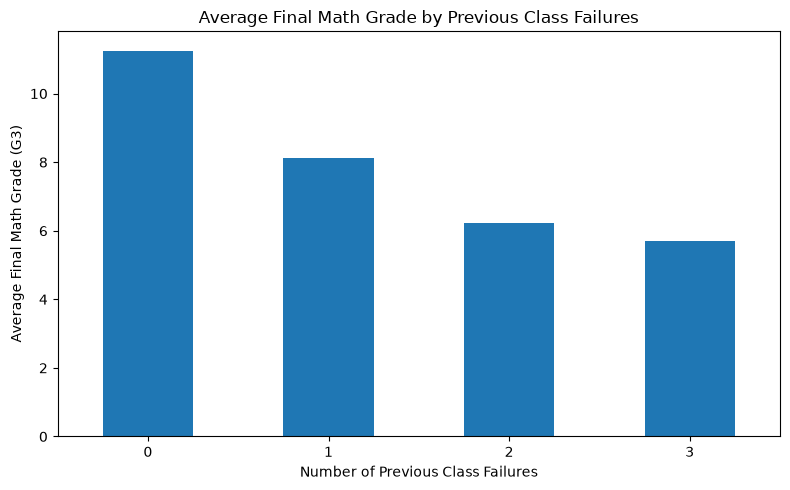

In [11]:
# Calculate the average final grade for each number of previous failures
average_grade_by_failures = df.groupby("failures")["G3"].mean()

# Create the bar chart
plt.figure(figsize=(8, 5))
average_grade_by_failures.plot(kind="bar")

plt.title("Average Final Math Grade by Previous Class Failures")
plt.xlabel("Number of Previous Class Failures")
plt.ylabel("Average Final Math Grade (G3)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Visualization Analysis

### Study Time and Final Grade

The first visualization shows the average final math grade for each study-time category. Students who reported more study time generally had slightly higher final grades. However, the differences between the groups were relatively small, suggesting that study time alone may not strongly explain differences in final grades.

### Absences and Final Grade

The second visualization shows the relationship between the number of school absences and final math grade. The points are widely spread, showing that students with similar numbers of absences can have very different final grades. This suggests that there is a weak relationship between absences and final grade in this dataset.

### Previous Class Failures and Final Grade

The third visualization shows the average final math grade for students with different numbers of previous class failures. This graph shows the clearest pattern of the three variables. Students with more previous class failures generally had lower average final grades.

In [12]:
# Calculate correlations between the main variables
correlations = df[["studytime", "absences", "failures", "G3"]].corr()

correlations["G3"].sort_values(ascending=False)

G3           1.000000
studytime    0.097820
absences     0.034247
failures    -0.360415
Name: G3, dtype: float64

In [13]:
# Create a binary pass/fail variable
df["passed"] = (df["G3"] >= 10).astype(int)

# Check how many students passed and failed
df["passed"].value_counts()

passed
1    265
0    130
Name: count, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Select the predictor variables
X = df[["studytime", "absences", "failures"]]

# Select final math grade as the target
y = df["G3"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train the model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions
y_pred = linear_model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.03074152988683987
RMSE: 4.458103940538365


In [15]:
# Display the linear regression coefficients

print("Intercept:", linear_model.intercept_)
print("Study time coefficient:", linear_model.coef_[0])
print("Absences coefficient:", linear_model.coef_[1])
print("Previous failures coefficient:", linear_model.coef_[2])

Intercept: 9.792179759530896
Study time coefficient: 0.5131770074191027
Absences coefficient: 0.04129383185056574
Previous failures coefficient: -2.268005830613942


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Use pass/fail as the classification target
y_class = df["passed"]

# Split the data into training and testing sets
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

# Create and train the logistic regression model
logistic_model = LogisticRegression()
logistic_model.fit(X_train_class, y_train_class)

# Make predictions
y_class_pred = logistic_model.predict(X_test_class)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_class, y_class_pred))
print("\nClassification Report:")
print(classification_report(y_test_class, y_class_pred))

Accuracy: 0.7341772151898734

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.33      0.46        27
           1       0.73      0.94      0.82        52

    accuracy                           0.73        79
   macro avg       0.74      0.64      0.64        79
weighted avg       0.74      0.73      0.70        79



In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create and train the decision tree
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train_class, y_train_class)

# Make predictions
tree_pred = tree_model.predict(X_test_class)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test_class, tree_pred))
print("\nClassification Report:")
print(classification_report(y_test_class, tree_pred))

Accuracy: 0.759493670886076

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.41      0.54        27
           1       0.75      0.94      0.84        52

    accuracy                           0.76        79
   macro avg       0.77      0.67      0.69        79
weighted avg       0.76      0.76      0.73        79



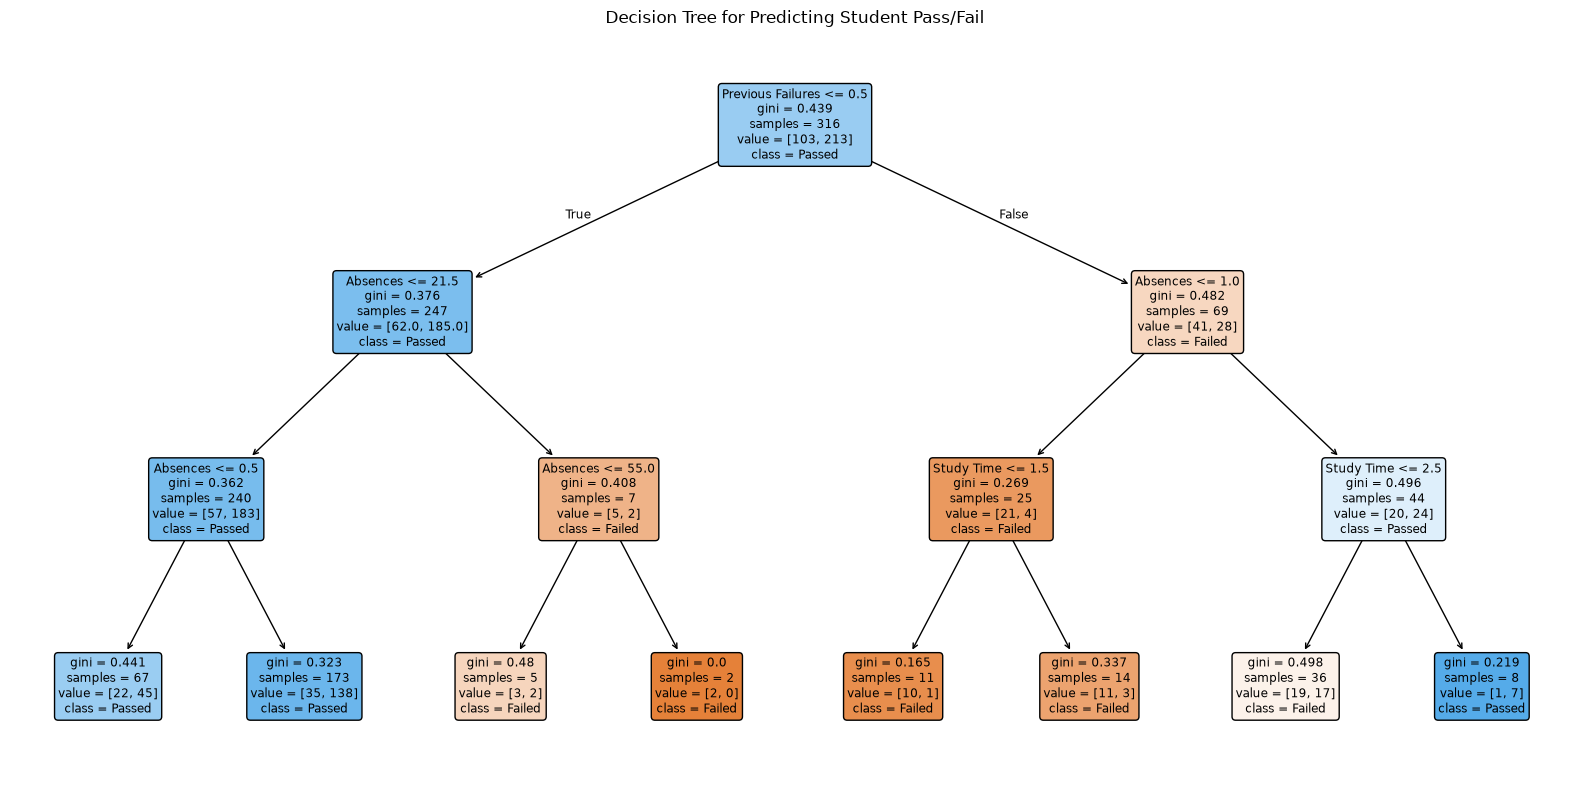

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualize the decision tree
plt.figure(figsize=(16, 8))

plot_tree(
    tree_model,
    feature_names=["Study Time", "Absences", "Previous Failures"],
    class_names=["Failed", "Passed"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Predicting Student Pass/Fail")
plt.tight_layout()
plt.show()

## Results

### Linear Regression

The linear regression model used study time, absences, and previous class failures to predict final math grades. The model had an R² of about 0.03, meaning that these three variables explained only about 3% of the variation in final grades. The RMSE was about 4.46 points on the 0–20 grading scale.

The model coefficients showed that previous class failures had the strongest relationship with final grade. The coefficient for failures was about -2.27, meaning that each additional previous failure was associated with about a 2.27-point decrease in predicted final grade when the other variables were held constant.

### Logistic Regression

The logistic regression model predicted whether a student passed or failed based on study time, absences, and previous class failures. The model had an accuracy of about 73.4% on the test data.

The model was better at identifying students who passed than students who failed. Its recall for passing students was about 0.94, while recall for failing students was about 0.33.

### Decision Tree

The decision tree also predicted whether students passed or failed. It achieved an accuracy of about 75.9%, which was slightly higher than the logistic regression model.

The tree showed that previous class failures were an important decision point. Absences and study time were also used to make predictions, but previous failures appeared near the top of the tree, suggesting that this variable was especially useful for classification.

### Overall Findings

Overall, previous class failures showed the clearest relationship with final math performance. Study time had a smaller relationship with grades, while absences showed very little linear relationship with final grade.

The classification models were able to predict passing and failing students with moderate accuracy, with the decision tree performing slightly better than logistic regression. However, the low R² from the linear regression shows that study time, absences, and previous failures alone do not explain most of the differences in students' final grades.

## Why This Question Matters

Understanding which student factors are associated with academic performance can help educators identify patterns that may deserve further attention. Students, teachers, and schools could use this type of analysis to better understand academic challenges and consider where additional support may be useful.

However, these results should not be used to label or predict an individual student's ability because the analysis is based on a limited observational dataset.

## Limitations and Potential Bias

There are several limitations to this analysis. First, the dataset only includes students from two Portuguese secondary schools, so the results may not apply to students from other schools, countries, or age groups.

Another limitation is that the analysis only uses study time, absences, and previous class failures to predict final grades. Other factors, such as motivation, family support, teaching quality, socioeconomic background, and access to academic resources could also affect student performance.

The study-time variable is reported in categories rather than exact numbers of hours, which limits how precisely study habits can be measured. In addition, the dataset is observational, so the results show relationships between variables but cannot prove that study time, absences, or previous failures directly cause changes in grades.

Finally, the classification models had moderate accuracy rather than perfect accuracy. This suggests that these three variables alone are not enough to accurately predict every student's performance.

### What I Would Explore Next

With more time and data, I would examine additional factors such as motivation, family support, socioeconomic background, and school characteristics. I would also compare the mathematics and Portuguese datasets to see whether the relationships found here are similar across subjects. Future analysis could use additional data from other schools or countries to test whether the patterns generalize.

## References

Aucejo, E. M., & Romano, T. F. (2016). Assessing the effect of school days and absences on test score performance. *Economics of Education Review, 55*, 70–87. https://doi.org/10.1016/j.econedurev.2016.08.007

Nonis, S. A., & Hudson, G. I. (2010). Performance of college students: Impact of study time and study habits. *Journal of Education for Business, 85*(4), 229–238. https://doi.org/10.1080/08832320903449550

Plant, E. A., Ericsson, K. A., Hill, L., & Asberg, K. (2005). Why study time does not predict grade point average across college students: Implications of deliberate practice for academic performance. *Contemporary Educational Psychology, 30*(1), 96–116. https://doi.org/10.1016/j.cedpsych.2004.06.001

UCI Machine Learning Repository. (2008). *Student performance* [Dataset]. https://doi.org/10.24432/C5TG7T

## AI Usage Disclosure

I used OpenAI ChatGPT to help brainstorm the research question, explain Python code and model outputs, troubleshoot coding errors, and improve the organization and wording of this project. I reviewed the suggestions and ran the analysis myself in Python.

## Conclusion

This analysis examined how study time, absences, and previous class failures relate to students' final math grades. Overall, previous class failures showed the strongest relationship with final grades, while study time had a smaller relationship and absences showed very little linear relationship.

The classification models were able to predict whether students passed or failed with moderate accuracy, with the decision tree performing slightly better than logistic regression. However, the results also show that these three variables alone cannot explain or predict student performance accurately.

Overall, this project demonstrates how data analysis and machine learning can be used to identify patterns in student performance while also recognizing the limitations of the available data.